<a href="https://colab.research.google.com/github/Sikaaaa3/Lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Janet Dankwah Nortey
Student ID: 23112028


In [49]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

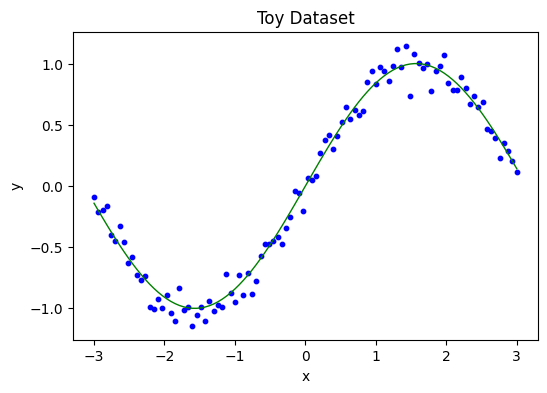

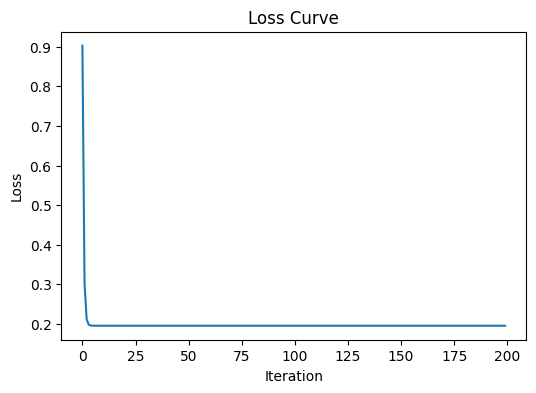

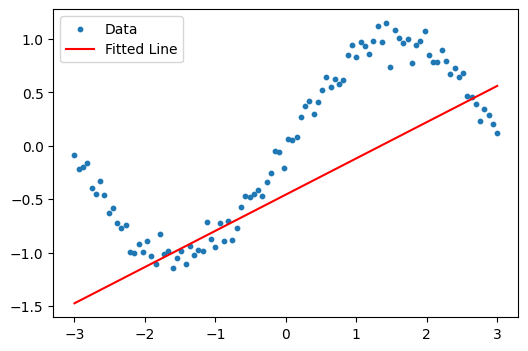

In [50]:
#Generate toy data
x = np.linspace(-3, 3, 100)
noise =np.random.normal(0,0.1,len(x))
y=np.sin(x) + noise

plt.figure(figsize=(6,4))
plt.scatter(x,y, s = 10, color="blue")
plt.plot(x, np.sin(x), color = "green", lw = 1, label = "true sin(x)")
plt. title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#Initialize parameters
w=np.random.randn() * 0.1
b=np.random.randn() *0.1

lr = 0.1
losses =[]

#Gradient Descent
for i in range(200):

  #Prediction
  y_hat = w * x

  #compute MSE loss
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  #compute gradients
  dw=np.mean(2 * (y_hat - y) * x)
  db=np.mean(2 * (y_hat -y))

  #update parameters
  w-= lr * dw
  b-= lr * db

#Plot loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show

#Plot fitted line
plt.figure(figsize=(6,4))
plt.scatter(x,y, s = 10, label="Data")
plt.plot(x,w * x+b, color = "red", label = "Fitted Line")
plt.legend()
plt.show()




Derive the dloss/dw by hand then post the picture here

**Part** 1.2 — Hidden layers and activations: why depth helps

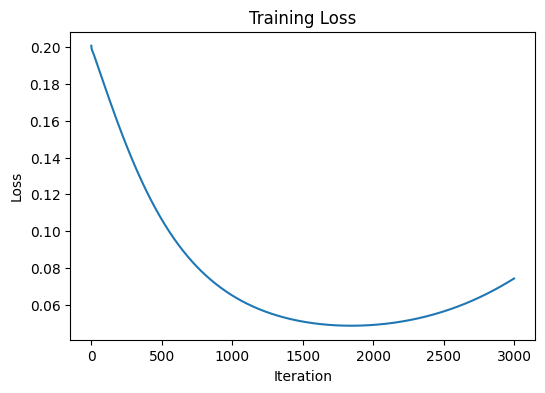

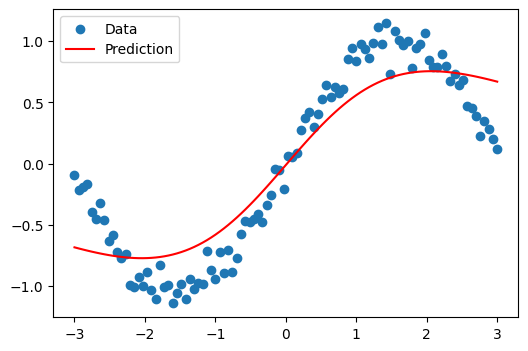

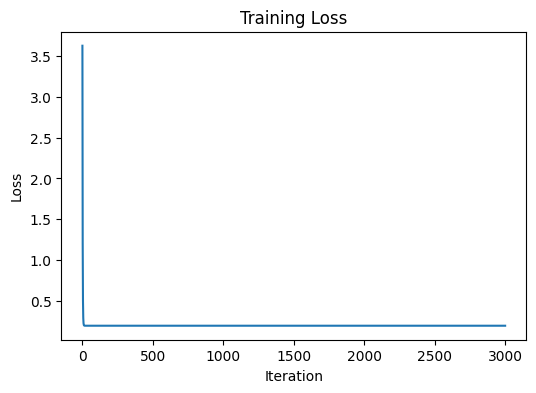

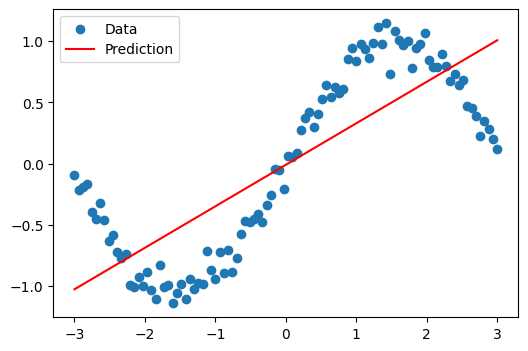

In [51]:
# Initialise parameter
x= x.reshape(-1,1)
y=y.reshape(-1,1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []

#Forward Pass
for i in range(3000):
      z1 = x @ W1 + b1
      h = np.tanh(z1)
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y) ** 2)
      losses.append(loss)

      # Backwards Pass
      d_yhat = 2 * (y_hat - y) / len(y)

      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh = d_yhat @ W2.T

      dz1 = dh
      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)

      #Update the Parameters
      W1 -= lr * dW1
      b1 -= lr * db1

      W2 -= lr * dW2
      b2 -= lr * db2

#Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Plot the final prediction
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()



#Re- Run with tanh

x= x.reshape(-1,1)
y=y.reshape(-1,1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []
#Forward Pass
for i in range(3000):
      z1 = x @ W1 + b1
      h = z1
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y) ** 2)
      losses.append(loss)

      # Backwards Pass
      d_yhat = 2 * (y_hat - y) / len(y)

      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh = d_yhat @ W2.T

      dz1 = dh

      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)

      #Update the Parameters
      W1 -= lr * dW1
      b1 -= lr * db1

      W2 -= lr * dW2
      b2 -= lr * db2

#Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Plot the final prediction
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()













You have to something here

Part 1.3 — The learning rate: too cold, too hot, just right


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1035/2413940732.py:18: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_1035/2413940732.py:25: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ w2.T
/tmp/ipykernel_1035/2413940732.py:26: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


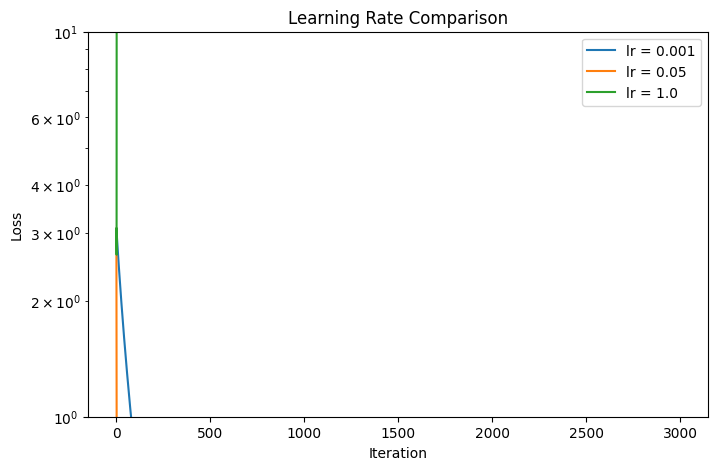

In [52]:
def train_toy(lr, steps=3000):
  np.random.seed(42)

  w1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)

  w2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)

  losses =[]

  for i in range(steps):
    #Forward pass
    z1 = x @ w1 + b1
    h = np.tanh(z1)
    y_hat = h @ w2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    #update
    w1 -= lr * dW1
    b1 -= lr * db1

    w2 -= lr * dW2
    b2 -= lr * db2

  return losses

#Training with the three learning rates
loss1 = train_toy(0.001)
loss2 = train_toy(0.05)
loss3 = train_toy(1.0)


#Plot of the three graph
plt.figure(figsize=(8,5))

plt.plot(loss1, label="lr = 0.001")
plt.plot(loss2, label="lr = 0.05")
plt.plot(loss3, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()

plt.show()








You have to do student Reasoning

Section 2 — A Real Feedforward Network in PyTorch

Part 2.1 — Preprocess and split (recycled from Lab 2)


In [58]:
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

#Load dataset
df = pd.read_csv(OBESITY_URL)

df.head()

# seperating features from the target
x= df.drop(columns = ["NObeyesdad"])
y=df["NObeyesdad"]

#One hot encoding on the categorical features
binary_cols =[
   "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC",
]
for col in binary_cols:
    x[col] = x[col].map({"no": 0, "yes": 1})

x["Gender"] = x["Gender"].map({
    "Female": 0,
    "Male": 1})

ordinal_cols=[
    "CAEC",
    "CALC"
    ]

frequency_order = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

for col in ordinal_cols:
    x[col] = x[col].map(frequency_order)


#One hot encoding on the categorical features
x = pd.get_dummies(
    x,
    columns=["MTRANS"],
    drop_first=False,
    dtype=int

)


#Label encode the target
from sklearn.preprocessing import LabelEncoder
label_encoder =LabelEncoder()
y=label_encoder.fit_transform(y)


from sklearn.model_selection import train_test_split

#first split
x_trainvali, x_test, y_trainvali, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

#Split into validation and test
x_train, x_validation, y_train, y_validation= train_test_split(
    x_trainvali,
    y_trainvali,
    test_size=0.25,
    stratify=y_trainvali,
    random_state=RANDOM_STATE
)


# standardizing the features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_val_scaled = scaler.transform(x_validation)
x_test_scaled = scaler.transform(x_test)

#converting to tensors
import torch
from torch.utils.data import TensorDataset, DataLoader

x_train_tensor = torch.tensor(x_train_scaled,dtype=torch.float32)
x_val_tensor = torch.tensor(x_val_scaled,dtype=torch.float32)
x_test_tensor = torch.tensor(x_test_scaled,dtype=torch.float32)


y_train_tensor = torch.tensor(y_train,dtype=torch.long)
y_val_tensor = torch.tensor(y_validation,dtype=torch.long)
y_test_tensor = torch.tensor(y_test,dtype=torch.long)


train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
val_dataset = TensorDataset(x_val_tensor,y_val_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)



Student Reasoning

Part 2.2 - Design the network

In [69]:

# TODO 1: Define the FeedForwardNet class


class FeedForwardNet(nn.Module):

    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()


        # Hidden Layer 1
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])

        # Activation function
        self.relu1 = nn.ReLU()


        # Hidden Layer 2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()

        # Output Layer
        self.classifier = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        out = self.classifier(x)

        return out

input_dim = x_train_tensor.shape[1]

model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7).to(DEVICE)

print(model)




# TODO 3: Count trainable parameters


num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Trainable Parameters:", num_params)



FeedForwardNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (classifier): Linear(in_features=32, out_features=7, bias=True)
)
Total Trainable Parameters: 3655


Part 2.3 - The training loop

Epoch 1/50 | Train Loss: 1.7461 | Train Acc: 45.58% | Val Loss: 1.7610 | Val Acc: 44.79%
Epoch 2/50 | Train Loss: 1.3756 | Train Acc: 51.42% | Val Loss: 1.3943 | Val Acc: 52.61%
Epoch 3/50 | Train Loss: 1.0643 | Train Acc: 62.16% | Val Loss: 1.0840 | Val Acc: 64.93%
Epoch 4/50 | Train Loss: 0.8764 | Train Acc: 73.30% | Val Loss: 0.8992 | Val Acc: 72.75%
Epoch 5/50 | Train Loss: 0.7457 | Train Acc: 76.30% | Val Loss: 0.7787 | Val Acc: 73.93%
Epoch 6/50 | Train Loss: 0.6491 | Train Acc: 76.54% | Val Loss: 0.6824 | Val Acc: 74.41%
Epoch 7/50 | Train Loss: 0.5685 | Train Acc: 81.12% | Val Loss: 0.6086 | Val Acc: 77.96%
Epoch 8/50 | Train Loss: 0.5019 | Train Acc: 84.12% | Val Loss: 0.5565 | Val Acc: 80.81%
Epoch 9/50 | Train Loss: 0.4436 | Train Acc: 86.65% | Val Loss: 0.5039 | Val Acc: 83.18%
Epoch 10/50 | Train Loss: 0.3961 | Train Acc: 88.23% | Val Loss: 0.4614 | Val Acc: 83.89%
Epoch 11/50 | Train Loss: 0.3561 | Train Acc: 89.18% | Val Loss: 0.4297 | Val Acc: 85.31%
Epoch 12/50 | Train

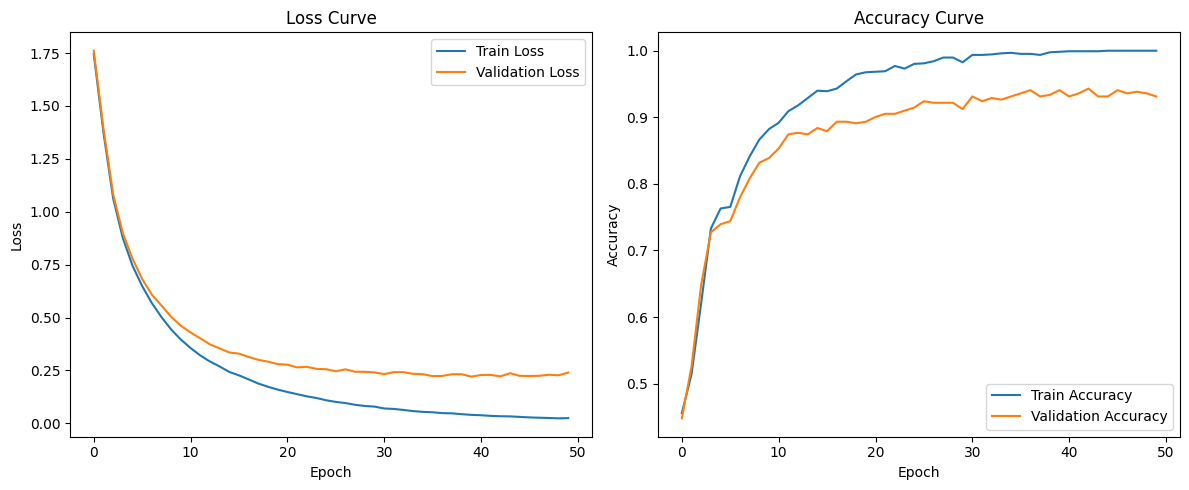

In [70]:
# Creating the loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Training the model
epochs = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(epochs):

    model.train()

    # Training on each batch
    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

    model.eval()

    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    # Evaluating the model
    with torch.no_grad():

        # Evaluating the training set
        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            train_loss_sum += loss.item() * yb.size(0)

            predictions = logits.argmax(dim=1)

            train_correct += (predictions == yb).sum().item()
            train_total += yb.size(0)

        # Evaluating the validation set
        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)

            predictions = logits.argmax(dim=1)

            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

    train_loss = train_loss_sum / train_total
    train_accuracy = train_correct / train_total

    val_loss = val_loss_sum / val_total
    val_accuracy = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Saving the best model
    if val_accuracy > best_val_acc:

        best_val_acc = val_accuracy

        torch.save(
            model.state_dict(),
            "ffn_best.pt"
        )

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}%"
    )

# Plotting the loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

# Plotting the accuracy curves
plt.subplot(1, 2, 2)

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.show()

Student Reasoning

Part 2.4 - Experiments: how training choices change the outcome

In [56]:
import torch
import torch.optim as optim

def run_experiment(hidden_sizes=(64,32),
                   lr=1e-3,
                   batch_size=32,
                   epochs=50,
                   dropout=0.0):

    model = FeedForwardNet(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        # -------- TRAIN --------
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(xb)

            loss = criterion(outputs, yb)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * xb.size(0)

            pred = outputs.argmax(1)

            correct += (pred == yb).sum().item()

            total += yb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- VALIDATION --------
        model.eval()

        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                outputs = model(xb)

                loss = criterion(outputs, yb)

                running_loss += loss.item() * xb.size(0)

                pred = outputs.argmax(1)

                correct += (pred == yb).sum().item()

                total += yb.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Acc={val_acc:.4f}"
        )

    return history